In [10]:
import pandas as pd
df = pd.read_csv('step1_etf_ohlcv.csv')


,Date,Ticker,Adj Close,Close,High,Low,Open,Volume,Mom_20
0,2021-01-04,SPY,342.436951,368.790009,375.450012,364.820007,375.309998,110210800,NaN
1,2021-01-04,XLB,32.192699,35.849998,36.700001,35.645000,36.514999,18266000,NaN
2,2021-01-04,XLC,62.922493,66.480003,67.790001,65.680000,67.750000,4456800,NaN
3,2021-01-04,XLE,15.498075,18.980000,19.330000,18.754999,19.170000,67717600,NaN
4,2021-01-04,XLF,26.443169,29.080000,29.600000,28.830000,29.590000,47086300,NaN
...,...,...,...,...,...,...,...,...,...
16615,2026-07-10,XLP,84.120003,84.120003,84.190002,83.169998,83.239998,8302600,-0.009198
16616,2026-07-10,XLRE,44.450001,44.450001,44.560001,44.049999,44.480000,3608200,-0.003345
16617,2026-07-10,XLU,45.410000,45.410000,45.480000,45.090000,45.119999,14050300,0.038636
16618,2026-07-10,XLV,160.839996,160.839996,162.660004,160.240005,162.479996,9496100,0.056914


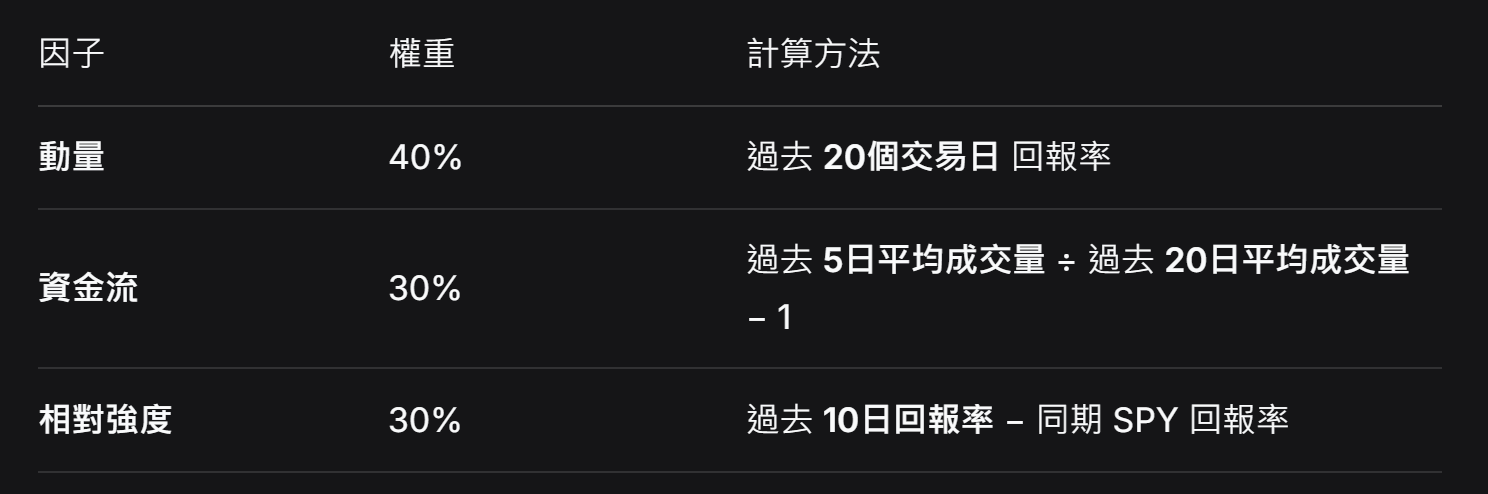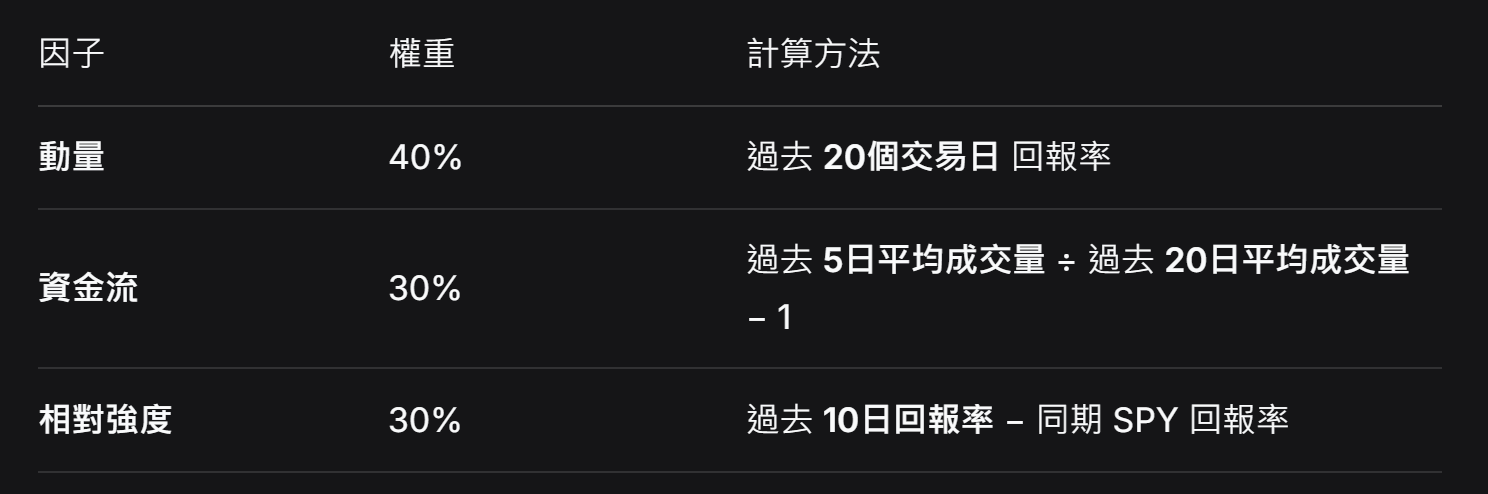

In [47]:
# factor 1 : 20 trading days return 動量
df['Mom_20'] = df.groupby('Ticker')['Adj Close'].pct_change(20)

# factor 2 : volume
df['Vol_5ma'] = df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(5).mean())
df['Vol_20ma'] = df.groupby('Ticker')['Volume'].transform(lambda x: x.rolling(20).mean())
df['Money_Flow'] = (df['Vol_5ma'] / df['Vol_20ma']) - 1

In [35]:
df.groupby('Ticker')[['Volume']].rolling(5).mean()

Volume
Ticker                  
SPY    0             NaN
       12            NaN
       24            NaN
       36            NaN
       48     85015740.0
...                  ...
XLY    16571   9112980.0
       16583   8833920.0
       16595  10808880.0
       16607  10540380.0
       16619   9558200.0

[16620 rows x 1 columns]